# BERT (Updated 1 Feb 2025, Available CUDA)

We shall implement BERT.  For this tutorial, you may want to first look at my Transformers tutorial to get a basic understanding of Transformers. 

For BERT, the main difference is on how we process the datasets, i.e., masking.   Aside from that, the backbone model is still the Transformers.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import math
import re
from   random import *
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os


In [4]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
device
print(device)

#make our work comparable if restarted the kernel
SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

torch.cuda.get_device_name(0)

cuda:3


'NVIDIA GeForce RTX 2080 Ti'

## 1. Data

For simplicity, we shall use very simple data like this.

In [5]:
from huggingface_hub import notebook_login

#this creates a secure login widget
notebook_login()

In [6]:
from datasets import load_dataset

dataset = load_dataset('PatrickHaller/wiki-and-book-corpus-500M', split='train[:1%]')

print(dataset[0])

{'train': 'jax was still recovering .'}


In [7]:
print(dataset[56422])

{'train': 'im pretty sure she witnessed something important and her statement would be more than enough to sentence this person to life imprisonment .'}


In [8]:
print(dataset)

Dataset({
    features: ['train'],
    num_rows: 156504
})


In [9]:
sentences = dataset['train']
text = [x.lower() for x in sentences] #lower case
text = [re.sub("[.,!?\\-]", ' ', x) for x in text] #clean all symbols
# text

In [10]:
for sentence in text:
    print(sentence, "_____")
    words = sentence.split()
    print(words)
    break

jax was still recovering   _____
['jax', 'was', 'still', 'recovering']


### Making vocabs

Before making the vocabs, let's remove all question marks and perios, etc, then turn everything to lowercase, and then simply split the text. 

In [11]:
from tqdm.auto import tqdm

# Combine everything into one to make vocab
word_list = list(set(" ".join(text).split()))
word2id = {'[PAD]': 0, '[CLS]': 1, '[SEP]': 2, '[MASK]': 3}  # special tokens

# Create the word2id in a single pass
for i, w in tqdm(enumerate(word_list), desc="Creating word2id"):
    word2id[w] = i + 4  # because 0-3 are already occupied

# Precompute the id2word mapping (this can be done once after word2id is fully populated)
id2word = {v: k for k, v in word2id.items()}
vocab_size = len(word2id)
vocab_size

Creating word2id: 0it [00:00, ?it/s]

207419

In [12]:
vocab_size = len(word2id)

# List of all tokens for the whole text
token_list = []

# Process sentences more efficiently
for sentence in tqdm(text, desc="Processing sentences"):
    token_list.append([word2id[word] for word in sentence.split()])

# Now token_list contains the tokenized sentences

Processing sentences:   0%|          | 0/156504 [00:00<?, ?it/s]

In [13]:
#take a look at sentences
sentences[:2]

['jax was still recovering .',
 'shrugging , i dipped my head back to wet my hair and slick it back out of my face .']

In [14]:
#take a look at token_list
token_list[:2]

[[95043, 9774, 173069, 136360],
 [97333,
  14780,
  108448,
  65612,
  12193,
  85898,
  79169,
  178812,
  65612,
  24153,
  116961,
  16807,
  38292,
  85898,
  202198,
  116612,
  65612,
  175099]]

In [15]:
#testing one sentence
for tokens in token_list[0]:
    print(id2word[tokens])

jax
was
still
recovering


## 2. Data loader

We gonna make dataloader.  Inside here, we need to make two types of embeddings: **token embedding** and **segment embedding**

1. **Token embedding** - Given “The cat is walking. The dog is barking”, we add [CLS] and [SEP] >> “[CLS] the cat is walking [SEP] the dog is barking”. 

2. **Segment embedding**
A segment embedding separates two sentences, i.e., [0 0 0 0 1 1 1 1 ]

3. **Masking**
As mentioned in the original paper, BERT randomly assigns masks to 15% of the sequence. In this 15%, 80% is replaced with masks, while 10% is replaced with random tokens, and the rest 10% is left as is.  Here we specified `max_pred` 

4. **Padding**
Once we mask, we will add padding. For simplicity, here we padded until some specified `max_len`. 

Note:  `positive` and `negative` are just simply counts to keep track of the batch size.  `positive` refers to two sentences that are really next to one another.

In [16]:
batch_size = 6
max_mask   = 20  # max masked tokens when 15% exceed, it will only be max_pred
max_len    = 128 # maximum of length to be padded; 

In [17]:
from random import random, randint, shuffle, randrange
def make_batch():
    batch = []
    positive = negative = 0  #count of batch size;  we want to have half batch that are positive pairs (i.e., next sentence pairs)
    while positive != batch_size/2 or negative != batch_size/2:
        
        #randomly choose two sentence so we can put [SEP]
        tokens_a_index, tokens_b_index = randrange(len(sentences)), randrange(len(sentences))
        #retrieve the two sentences
        tokens_a, tokens_b = token_list[tokens_a_index], token_list[tokens_b_index]

        # TRUNCATION LOGIC
        # BERT usually has: [CLS] + tokens_a + [SEP] + tokens_b + [SEP]
        # Total special tokens = 3. So tokens_a + tokens_b must be <= (max_len - 3)
        # We truncate them proportionally so the total length is exactly max_len or less.
        max_num_tokens = max_len - 3
        while len(tokens_a) + len(tokens_b) > max_num_tokens:
            if len(tokens_a) > len(tokens_b):
                tokens_a.pop()
            else:
                tokens_b.pop()

        #1. token embedding - append CLS and SEP
        input_ids = [word2id['[CLS]']] + tokens_a + [word2id['[SEP]']] + tokens_b + [word2id['[SEP]']]

        #2. segment embedding - [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
        segment_ids = [0] * (1 + len(tokens_a) + 1) + [1] * (len(tokens_b) + 1)

        #3. mask language modeling
        #masked 15%, but should be at least 1 but does not exceed max_mask
        n_pred =  min(max_mask, max(1, int(round(len(input_ids) * 0.15))))
        #get the pos that excludes CLS and SEP and shuffle them
        cand_maked_pos = [i for i, token in enumerate(input_ids) if token != word2id['[CLS]'] and token != word2id['[SEP]']]
        shuffle(cand_maked_pos)
        masked_tokens, masked_pos = [], []
        #simply loop and change the input_ids to [MASK]
        for pos in cand_maked_pos[:n_pred]:
            masked_pos.append(pos)  #remember the position
            masked_tokens.append(input_ids[pos]) #remember the tokens
            #80% replace with a [MASK], but 10% will replace with a random token
            if random() < 0.1:  # 10%
                index = randint(0, vocab_size - 1) # random index in vocabulary
                input_ids[pos] = word2id[id2word[index]] # replace
            elif random() < 0.9:  # 80%
                input_ids[pos] = word2id['[MASK]'] # make mask
            else:  #10% do nothing
                pass

        # pad the input_ids and segment ids until the max len
        n_pad = max_len - len(input_ids)
        input_ids.extend([0] * n_pad)
        segment_ids.extend([0] * n_pad)

        # pad the masked_tokens and masked_pos to make sure the lenth is max_mask
        if max_mask > n_pred:
            n_pad = max_mask - n_pred
            masked_tokens.extend([0] * n_pad)
            masked_pos.extend([0] * n_pad)

        #check if first sentence is really comes before the second sentence
        #also make sure positive is exactly half the batch size
        if tokens_a_index + 1 == tokens_b_index and positive < batch_size / 2:
            batch.append([input_ids, segment_ids, masked_tokens, masked_pos, True]) # IsNext
            positive += 1
        elif tokens_a_index + 1 != tokens_b_index and negative < batch_size/2:
            batch.append([input_ids, segment_ids, masked_tokens, masked_pos, False]) # NotNext
            negative += 1
            
    return batch

In [18]:
batch = make_batch()

In [19]:
#len of batch
len(batch)

6

In [20]:
#we can deconstruct using map and zip
input_ids, segment_ids, masked_tokens, masked_pos, isNext = map(torch.LongTensor, zip(*batch))
input_ids.shape, segment_ids.shape, masked_tokens.shape, masked_pos.shape, isNext.shape

(torch.Size([6, 128]),
 torch.Size([6, 128]),
 torch.Size([6, 20]),
 torch.Size([6, 20]),
 torch.Size([6]))

## 3. Model

Recall that BERT only uses the encoder.

BERT has the following components:

- Embedding layers
- Attention Mask
- Encoder layer
- Multi-head attention
- Scaled dot product attention
- Position-wise feed-forward network
- BERT (assembling all the components)

## 3.1 Embedding

Here we simply generate the positional embedding, and sum the token embedding, positional embedding, and segment embedding together.

<img src = "figures/BERT_embed.png" width=500>

In [21]:
class Embedding(nn.Module):
    def __init__(self, vocab_size, max_len, n_segments, d_model, device):
        super(Embedding, self).__init__()
        self.tok_embed = nn.Embedding(vocab_size, d_model)  # token embedding
        self.pos_embed = nn.Embedding(max_len, d_model)      # position embedding
        self.seg_embed = nn.Embedding(n_segments, d_model)  # segment(token type) embedding
        self.norm = nn.LayerNorm(d_model)
        self.device = device

    def forward(self, x, seg):
        #x, seg: (bs, len)
        seq_len = x.size(1)
        pos = torch.arange(seq_len, dtype=torch.long).to(self.device)
        pos = pos.unsqueeze(0).expand_as(x)  # (len,) -> (bs, len)
        embedding = self.tok_embed(x) + self.pos_embed(pos) + self.seg_embed(seg)
        return self.norm(embedding)

## 3.2 Attention mask

In [22]:
def get_attn_pad_mask(seq_q, seq_k, device):
    batch_size, len_q = seq_q.size()
    batch_size, len_k = seq_k.size()
    # eq(zero) is PAD token
    pad_attn_mask = seq_k.data.eq(0).unsqueeze(1).to(device)  # batch_size x 1 x len_k(=len_q), one is masking
    return pad_attn_mask.expand(batch_size, len_q, len_k)  # batch_size x len_q x len_k

### Testing the attention mask

In [23]:
print(get_attn_pad_mask(input_ids, input_ids, device).shape)

torch.Size([6, 128, 128])


## 3.3 Encoder

The encoder has two main components: 

- Multi-head Attention
- Position-wise feed-forward network

First let's make the wrapper called `EncoderLayer`

In [24]:
class EncoderLayer(nn.Module):
    def __init__(self, n_heads, d_model, d_ff, d_k, device):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(n_heads, d_model, d_k, device)
        self.pos_ffn       = PoswiseFeedForwardNet(d_model, d_ff)

    def forward(self, enc_inputs, enc_self_attn_mask):
        enc_outputs, attn = self.enc_self_attn(enc_inputs, enc_inputs, enc_inputs, enc_self_attn_mask) # enc_inputs to same Q,K,V
        enc_outputs = self.pos_ffn(enc_outputs) # enc_outputs: [batch_size x len_q x d_model]
        return enc_outputs, attn

Let's define the scaled dot attention, to be used inside the multihead attention

In [25]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k, device):
        super(ScaledDotProductAttention, self).__init__()
        self.scale = torch.sqrt(torch.FloatTensor([d_k])).to(device)

    def forward(self, Q, K, V, attn_mask):
        scores = torch.matmul(Q, K.transpose(-1, -2)) / self.scale # scores : [batch_size x n_heads x len_q(=len_k) x len_k(=len_q)]
        scores.masked_fill_(attn_mask, -1e9) # Fills elements of self tensor with value where mask is one.
        attn = nn.Softmax(dim=-1)(scores)
        context = torch.matmul(attn, V)
        return context, attn 

Let's define the parameters first

In [26]:
n_layers = 6    # number of Encoder of Encoder Layer
n_heads  = 8    # number of heads in Multi-Head Attention
d_model  = 768  # Embedding Size
d_ff = 768 * 4  # 4*d_model, FeedForward dimension
d_k = d_v = 64  # dimension of K(=Q), V
n_segments = 2

Here is the Multiheadattention.

In [27]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, d_k, device):
        super(MultiHeadAttention, self).__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_k = d_k
        self.d_v = d_k
        self.W_Q = nn.Linear(d_model, d_k * n_heads)
        self.W_K = nn.Linear(d_model, d_k * n_heads)
        self.W_V = nn.Linear(d_model, self.d_v * n_heads)
        self.W_O = nn.Linear(n_heads * self.d_v, d_model)
        self.device = device
    def forward(self, Q, K, V, attn_mask):
        # q: [batch_size x len_q x d_model], k: [batch_size x len_k x d_model], v: [batch_size x len_k x d_model]
        residual, batch_size = Q, Q.size(0)
        # (B, S, D) -proj-> (B, S, D) -split-> (B, S, H, W) -trans-> (B, H, S, W)
        q_s = self.W_Q(Q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1,2)  # q_s: [batch_size x n_heads x len_q x d_k]
        k_s = self.W_K(K).view(batch_size, -1, self.n_heads, self.d_k).transpose(1,2)  # k_s: [batch_size x n_heads x len_k x d_k]
        v_s = self.W_V(V).view(batch_size, -1, self.n_heads, self.d_v).transpose(1,2)  # v_s: [batch_size x n_heads x len_k x d_v]

        attn_mask = attn_mask.unsqueeze(1).repeat(1, self.n_heads, 1, 1) # attn_mask : [batch_size x n_heads x len_q x len_k]

        # context: [batch_size x n_heads x len_q x d_v], attn: [batch_size x n_heads x len_q(=len_k) x len_k(=len_q)]
        context, attn = ScaledDotProductAttention(self.d_k, self.device)(q_s, k_s, v_s, attn_mask)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.n_heads * self.d_v) # context: [batch_size x len_q x n_heads * d_v]
        output = nn.Linear(self.n_heads * self.d_v, self.d_model, device=self.device)(context)
        output = self.W_O(output)
        return nn.LayerNorm(self.d_model, device=self.device)(output + residual), attn # output: [batch_size x len_q x d_model]

Here is the PoswiseFeedForwardNet.

In [28]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        # (batch_size, len_seq, d_model) -> (batch_size, len_seq, d_ff) -> (batch_size, len_seq, d_model)
        return self.fc2(F.gelu(self.fc1(x)))

## 3.4 Putting them together

In [29]:
class BERT(nn.Module):
    def __init__(self, n_layers, n_heads, d_model, d_ff, d_k, n_segments, vocab_size, max_len, device):
        super(BERT, self).__init__()
        self.params = {'n_layers': n_layers, 'n_heads': n_heads, 'd_model': d_model,
                       'd_ff': d_ff, 'd_k': d_k, 'n_segments': n_segments,
                       'vocab_size': vocab_size, 'max_len': max_len}
        self.embedding = Embedding(vocab_size, max_len, n_segments, d_model, device)
        self.layers = nn.ModuleList([EncoderLayer(n_heads, d_model, d_ff, d_k, device) for _ in range(n_layers)])
        self.fc = nn.Linear(d_model, d_model)
        self.activ = nn.Tanh()
        self.linear = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, 2)
        # decoder is shared with embedding layer
        embed_weight = self.embedding.tok_embed.weight
        n_vocab, n_dim = embed_weight.size()
        self.decoder = nn.Linear(n_dim, n_vocab, bias=False)
        self.decoder.weight = embed_weight
        self.decoder_bias = nn.Parameter(torch.zeros(n_vocab))
        self.device = device

    # def forward(self, input_ids, segment_ids, masked_pos):
    #     output = self.embedding(input_ids, segment_ids)
    #     enc_self_attn_mask = get_attn_pad_mask(input_ids, input_ids, self.device)
    #     for layer in self.layers:
    #         output, enc_self_attn = layer(output, enc_self_attn_mask)
    #     # output : [batch_size, len, d_model], attn : [batch_size, n_heads, d_mode, d_model]
        
    #     # 1. predict next sentence
    #     # it will be decided by first token(CLS)
    #     h_pooled   = self.activ(self.fc(output[:, 0])) # [batch_size, d_model]
    #     logits_nsp = self.classifier(h_pooled) # [batch_size, 2]

    #     # 2. predict the masked token
    #     masked_pos = masked_pos[:, :, None].expand(-1, -1, output.size(-1)) # [batch_size, max_pred, d_model]
    #     h_masked = torch.gather(output, 1, masked_pos) # masking position [batch_size, max_pred, d_model]
    #     h_masked  = self.norm(F.gelu(self.linear(h_masked)))
    #     logits_lm = self.decoder(h_masked) + self.decoder_bias # [batch_size, max_pred, n_vocab]
    
        # return logits_lm, logits_nsp
    def forward(self, input_ids, segment_ids, masked_pos):
        #get embeddings (token + position + segment)
        output = self.embedding(input_ids, segment_ids)
        
        #get attention mask for padding
        enc_self_attn_mask = get_attn_pad_mask(input_ids, input_ids, self.device)
        
        #pass through transformer encoder layers
        for layer in self.layers:
            output, enc_self_attn = layer(output, enc_self_attn_mask)
        
        # --- CRITICAL FOR TASK 2 ---
        # Capture the hidden state here. 
        # Dimension: [batch_size, seq_len, d_model] (e.g., [32, 128, 768])
        last_hidden_state = output 

        #task 1 -> Next Sentence Prediction (NSP) Logic
        # Uses the first token [CLS]
        h_pooled = self.activ(self.fc(output[:, 0])) 
        logits_nsp = self.classifier(h_pooled) 

        #task 1 -> Masked Language Model (MLM) Logic
        # Expand masked_pos to match the hidden state dimension
        masked_pos_expanded = masked_pos[:, :, None].expand(-1, -1, output.size(-1)) 
        
        #gather specific tokens that were masked
        h_masked = torch.gather(output, 1, masked_pos_expanded) 
        h_masked = self.norm(F.gelu(self.linear(h_masked)))
        
        #decode back to vocabulary size
        logits_lm = self.decoder(h_masked) + self.decoder_bias 

        #return all three: MLM logits, NSP logits, and the Hidden States
        return logits_lm, logits_nsp, last_hidden_state
    
    def get_last_hidden_state(self, input_ids, segment_ids):
        output = self.embedding(input_ids, segment_ids)
        enc_self_attn_mask = get_attn_pad_mask(input_ids, input_ids, self.device)
        for layer in self.layers:
            output, enc_self_attn = layer(output, enc_self_attn_mask)

        return output

## 4. Training

In [30]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, std=0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [31]:
max_len = 128    # reduced from 1000 to prevent OOM
batch_size = 16  # slightly larger batch for stability
num_epoch = 100 
accumulation_steps = 4 # Effective batch size = batch_size * accumulation_steps

model = BERT(
    n_layers=12, # number of Encoder of Encoder Layer
    n_heads=12,  # number of heads in Multi-Head Attention
    d_model=768,  # Embedding Size
    d_ff=3072, # 4*d_model, FeedForward dimension
    d_k=64, # dimension of K(=Q), V
    n_segments=2, 
    vocab_size=vocab_size, 
    max_len=max_len, 
    device=device
).to(device)

model.apply(init_weights)

BERT(
  (embedding): Embedding(
    (tok_embed): Embedding(207419, 768)
    (pos_embed): Embedding(128, 768)
    (seg_embed): Embedding(2, 768)
    (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (layers): ModuleList(
    (0-11): 12 x EncoderLayer(
      (enc_self_attn): MultiHeadAttention(
        (W_Q): Linear(in_features=768, out_features=768, bias=True)
        (W_K): Linear(in_features=768, out_features=768, bias=True)
        (W_V): Linear(in_features=768, out_features=768, bias=True)
        (W_O): Linear(in_features=768, out_features=768, bias=True)
      )
      (pos_ffn): PoswiseFeedForwardNet(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
      )
    )
  )
  (fc): Linear(in_features=768, out_features=768, bias=True)
  (activ): Tanh()
  (linear): Linear(in_features=768, out_features=768, bias=True)
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (c

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.0
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [33]:
num_epoch = 100
batches_per_epoch = 15  # Increased slightly for better stability
patience = 5
best_loss = float('inf')
counter = 0

history = {'loss': [], 'mlm_loss': [], 'nsp_loss': []}

model.train()
pbar = tqdm(range(num_epoch), desc="Training BERT")

for epoch in pbar:
    epoch_loss = 0
    epoch_mlm_loss = 0
    epoch_nsp_loss = 0
    
    for _ in range(batches_per_epoch):
        # generate Batch
        batch = make_batch()
        input_ids, segment_ids, masked_tokens, masked_pos, isNext = map(torch.LongTensor, zip(*batch))
        
        input_ids = input_ids.to(device)
        segment_ids = segment_ids.to(device)
        masked_tokens = masked_tokens.to(device)
        masked_pos = masked_pos.to(device)
        isNext = isNext.to(device)

        #forward Pass
        optimizer.zero_grad()
        logits_lm, logits_nsp, _ = model(input_ids, segment_ids, masked_pos)
        
        #loss Calculation
        loss_lm = criterion(logits_lm.view(-1, vocab_size), masked_tokens.view(-1))
        loss_nsp = criterion(logits_nsp, isNext)
        loss = loss_lm + loss_nsp
        
        #backward Pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Prevents exploding gradients
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_mlm_loss += loss_lm.item()
        epoch_nsp_loss += loss_nsp.item()

    #average epoch metrics
    avg_loss = epoch_loss / batches_per_epoch
    avg_mlm = epoch_mlm_loss / batches_per_epoch
    avg_nsp = epoch_nsp_loss / batches_per_epoch
    
    history['loss'].append(avg_loss)
    history['mlm_loss'].append(avg_mlm)
    history['nsp_loss'].append(avg_nsp)
    
    #logging & progress bar
    pbar.set_postfix({
        'Total': f"{avg_loss:.4f}", 
        'MLM': f"{avg_mlm:.4f}", 
        'NSP': f"{avg_nsp:.4f}"
    })

    print(f"Epoch [{epoch+1}/{num_epoch}] -> Loss: {avg_loss:.4f} | MLM Loss: {avg_mlm:.4f} | NSP Loss: {avg_nsp:.4f}")

    #early stopping & checkpointing
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), 'best_bert_model.pth')
        counter = 0  # Reset counter if we improved
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}. No improvement for {patience} epochs.")
            break

print(f"Training complete. Best Loss: {best_loss:.4f}")

Training BERT:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch [1/100] -> Loss: 6.7747 | MLM Loss: 6.0794 | NSP Loss: 0.6953
Epoch [2/100] -> Loss: 3.6131 | MLM Loss: 2.9199 | NSP Loss: 0.6932
Epoch [3/100] -> Loss: 3.3974 | MLM Loss: 2.7041 | NSP Loss: 0.6932
Epoch [4/100] -> Loss: 3.3381 | MLM Loss: 2.6448 | NSP Loss: 0.6934
Epoch [5/100] -> Loss: 3.2373 | MLM Loss: 2.5440 | NSP Loss: 0.6933
Epoch [6/100] -> Loss: 3.2819 | MLM Loss: 2.5887 | NSP Loss: 0.6932
Epoch [7/100] -> Loss: 3.1892 | MLM Loss: 2.4960 | NSP Loss: 0.6933
Epoch [8/100] -> Loss: 3.2741 | MLM Loss: 2.5809 | NSP Loss: 0.6932
Epoch [9/100] -> Loss: 3.1599 | MLM Loss: 2.4666 | NSP Loss: 0.6933
Epoch [10/100] -> Loss: 3.1717 | MLM Loss: 2.4786 | NSP Loss: 0.6931
Epoch [11/100] -> Loss: 3.2598 | MLM Loss: 2.5666 | NSP Loss: 0.6933
Epoch [12/100] -> Loss: 2.9216 | MLM Loss: 2.2283 | NSP Loss: 0.6932
Epoch [13/100] -> Loss: 3.0176 | MLM Loss: 2.3244 | NSP Loss: 0.6932
Epoch [14/100] -> Loss: 3.0409 | MLM Loss: 2.3477 | NSP Loss: 0.6932
Epoch [15/100] -> Loss: 3.0050 | MLM Loss: 

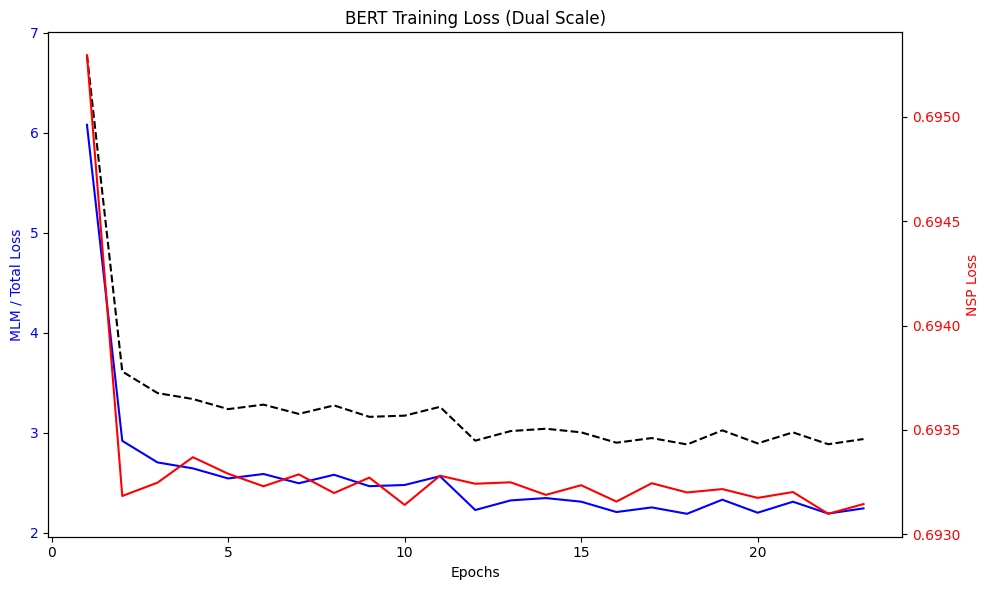

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

def plot_history(history):
    epochs = range(1, len(history['loss']) + 1)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Left axis for MLM and Total Loss
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('MLM / Total Loss', color='blue')
    ax1.plot(epochs, history['loss'], label='Total Loss', color='black', linestyle='--')
    ax1.plot(epochs, history['mlm_loss'], label='MLM Loss', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Right axis for NSP Loss
    ax2 = ax1.twinx() 
    ax2.set_ylabel('NSP Loss', color='red')
    ax2.plot(epochs, history['nsp_loss'], label='NSP Loss', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title('BERT Training Loss (Dual Scale)')
    fig.tight_layout()
    fig.savefig('figures/loss.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history)

In [35]:
#predict mask tokens and isNext
#we pick a specific index from the batch (e.g., index 2)
input_ids, segment_ids, masked_tokens, masked_pos, isNext = map(torch.LongTensor, zip(batch[2]))

print("Input Sentence: ", [id2word[w.item()] for w in input_ids[0] if id2word[w.item()] != '[PAD]'])

input_ids = input_ids.to(device)
segment_ids = segment_ids.to(device)
masked_tokens = masked_tokens.to(device)
masked_pos = masked_pos.to(device)
isNext = isNext.to(device)

# Forward pass
model.eval()
with torch.no_grad():
    logits_lm, logits_nsp,_ = model(input_ids, segment_ids, masked_pos)

#Predict masked tokens using Pure PyTorch
# logits_lm: [1, max_mask, vocab_size]
predict_lm = logits_lm.argmax(dim=2)[0] # Get indices of max logit

print('\n' + '='*30)
# We filter out index 0 (PAD) if it exists in masked tokens
print('Actual masked tokens (words) : ', [id2word[pos.item()] for pos in masked_tokens[0] if pos.item() != 0])
print('Actual masked tokens list    : ', [pos.item() for pos in masked_tokens[0] if pos.item() != 0])
print('Predict masked tokens (words): ', [id2word[pos.item()] for pos in predict_lm if pos.item() != 0])
print('Predict masked tokens list   : ', [pos.item() for pos in predict_lm if pos.item() != 0])

#Predict NSP using Pure PyTorch
predict_nsp = logits_nsp.argmax(dim=1).item()

print('='*30)
print('isNext (Actual)   : ', True if isNext[0].item() else False)
print('isNext (Predicted): ', True if predict_nsp else False)

Input Sentence:  ['[CLS]', 'you', '[MASK]', 'for', 'the', 'girls', 'physical', 'needs', 'keeping', 'them', 'safe', 'and', 'you', 'made', 'a', 'lovely', 'deck', 'and', 'you', 'cared', 'for', 'their', '[MASK]', '[MASK]', '[SEP]', 'amanda', 'hissed', 'in', 'pleasure', 'as', 'his', '[MASK]', 'teased', 'her', 'relentlessly', '[SEP]']

Actual masked tokens (words) :  ['fingers', 'girls', 'spiritual', 'needs', 'cared']
Actual masked tokens list    :  [12127, 19705, 178957, 178690, 25598]
Predict masked tokens (words):  ['the', 'the', 'the', 'the', 'the']
Predict masked tokens list   :  [97326, 97326, 97326, 97326, 97326]
isNext (Actual)   :  False
isNext (Predicted):  True
